# Simple Linear Regression on Advertising Dataset

## Objective
In this notebook, we apply **Simple Linear Regression** to the Advertising dataset to model the relationship between individual advertising channels and Sales. We build three models:

1. **TV → Sales** (as discussed in the lecture)
2. **Newspaper → Sales**
3. **Radio → Sales**

We then evaluate and compare all three models using standard regression evaluation metrics to determine which advertising channel is the best predictor of Sales.

---
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

---
## 2. Load and Explore the Dataset

In [2]:
# Load the advertising dataset
df = pd.read_csv('advertising.csv')

# Display basic information
print('Shape of the dataset:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape of the dataset: (200, 4)

First 5 rows:


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [3]:
# Statistical summary
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [4]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())
print('\nData types:')
print(df.dtypes)

Missing values per column:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Data types:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object


**Observation:** The dataset contains 200 observations with 4 columns — `TV`, `Radio`, `Newspaper` (advertising budgets in thousands of dollars), and `Sales` (in thousands of units). There are no missing values.

---
## 3. Exploratory Data Analysis (EDA)

Let's visualize the relationship between each advertising channel and Sales to get an initial understanding before building the models.

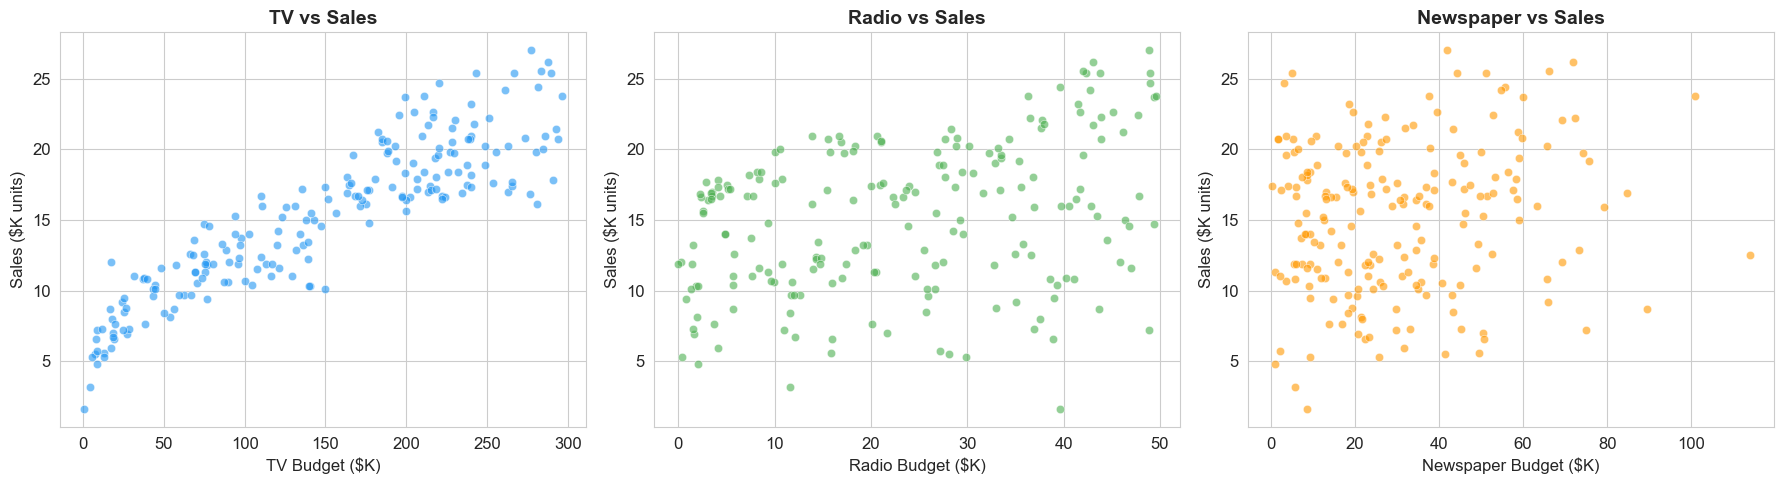

In [5]:
# Scatter plots for each feature vs Sales
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = ['TV', 'Radio', 'Newspaper']
colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, (feature, color) in enumerate(zip(features, colors)):
    axes[i].scatter(df[feature], df['Sales'], alpha=0.6, color=color, edgecolors='white', linewidth=0.5)
    axes[i].set_xlabel(feature + ' Budget ($K)', fontsize=12)
    axes[i].set_ylabel('Sales ($K units)', fontsize=12)
    axes[i].set_title(f'{feature} vs Sales', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Observations from the scatter plots:**
- **TV vs Sales:** Shows a clear positive linear trend. Higher TV budgets are associated with higher sales.
- **Radio vs Sales:** Shows a moderate positive trend, but with more spread/variability.
- **Newspaper vs Sales:** Shows a weak relationship with significant scatter. The linear association appears minimal.

Correlation with Sales:
Sales        1.000000
TV           0.901208
Radio        0.349631
Newspaper    0.157960
Name: Sales, dtype: float64



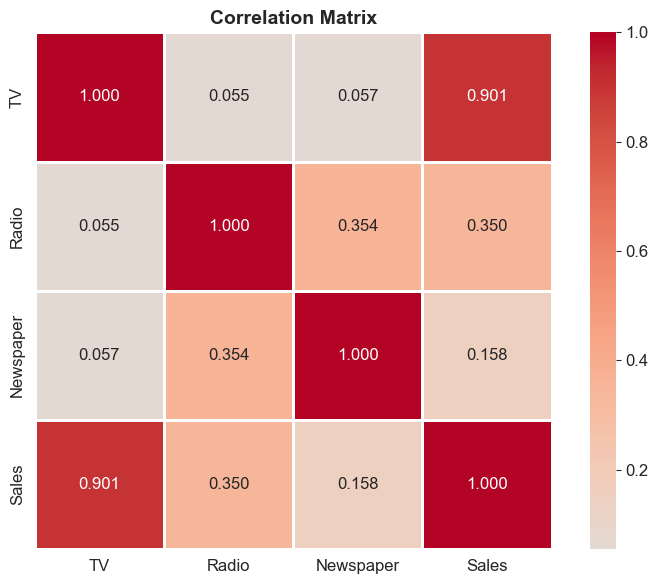

In [6]:
# Correlation matrix
print('Correlation with Sales:')
print(df.corr()['Sales'].sort_values(ascending=False))
print()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.3f',
            square=True, linewidths=1)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** The correlation values confirm our visual observations:
- TV has the highest correlation with Sales (~0.90)
- Radio has a moderate correlation (~0.35)
- Newspaper has the weakest correlation (~0.16)

---
## 4. Simple Linear Regression Models

We will build three separate simple linear regression models, each using a single feature (TV, Radio, or Newspaper) to predict Sales.

### Helper Function for Model Building & Evaluation

In [7]:
def build_and_evaluate_model(df, feature_name, target='Sales', test_size=0.3, random_state=42):
    """
    Build a Simple Linear Regression model and evaluate it.
    
    Parameters:
    -----------
    df : DataFrame - the dataset
    feature_name : str - the independent variable column name
    target : str - the dependent variable column name
    test_size : float - proportion of data for testing
    random_state : int - random seed for reproducibility
    
    Returns:
    --------
    dict : dictionary containing model details and evaluation metrics
    """
    # Define X and y
    X = df[[feature_name]]
    y = df[target]
    
    # Split the data into training and testing sets (70-30 split)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    print(f'Training set size: {len(X_train)}')
    print(f'Testing set size:  {len(X_test)}')
    
    # Create and fit the model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Model coefficients
    intercept = model.intercept_
    slope = model.coef_[0]
    print(f'\nRegression Equation: Sales = {intercept:.4f} + {slope:.4f} × {feature_name}')
    print(f'Intercept (β0): {intercept:.4f}')
    print(f'Slope (β1):     {slope:.4f}')
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Evaluation metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f'\n--- Evaluation Metrics (Test Set) ---')
    print(f'R² Score:                    {r2:.4f}')
    print(f'Mean Squared Error (MSE):    {mse:.4f}')
    print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
    print(f'Mean Absolute Error (MAE):   {mae:.4f}')
    
    return {
        'feature': feature_name,
        'model': model,
        'intercept': intercept,
        'slope': slope,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred,
        'R2': r2,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae
    }

---
### 4.1 Model 1: TV → Sales (Lecture Model)

In [8]:
print('='*60)
print('MODEL 1: TV → Sales (Lecture Model)')
print('='*60)
results_tv = build_and_evaluate_model(df, 'TV')

MODEL 1: TV → Sales (Lecture Model)
Training set size: 140
Testing set size:  60

Regression Equation: Sales = 7.2066 + 0.0548 × TV
Intercept (β0): 7.2066
Slope (β1):     0.0548

--- Evaluation Metrics (Test Set) ---
R² Score:                    0.8149
Mean Squared Error (MSE):    5.1795
Root Mean Squared Error (RMSE): 2.2759
Mean Absolute Error (MAE):   1.8069


/opt/anaconda3/envs/DS201/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


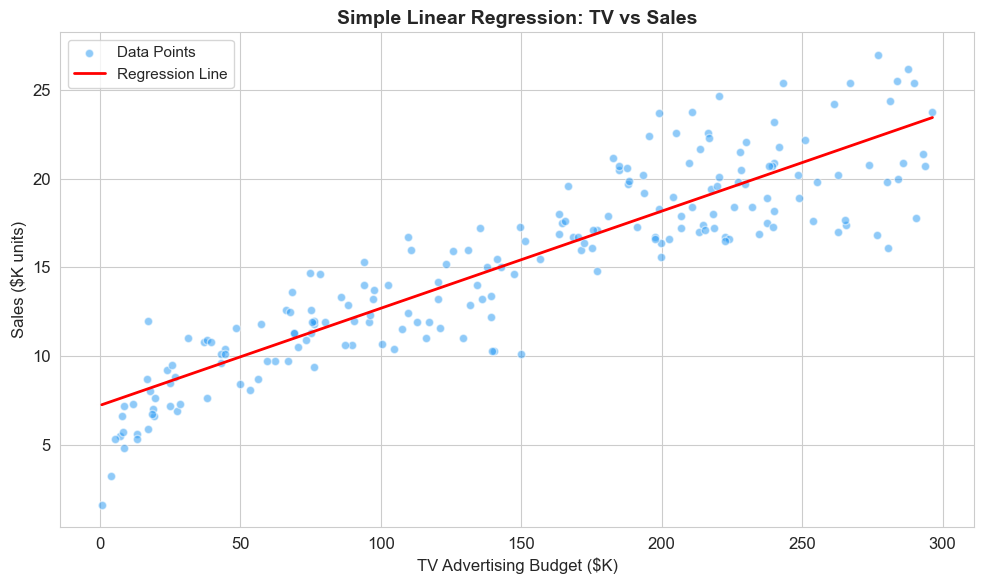

In [9]:
# Visualization: Regression line for TV vs Sales
plt.figure(figsize=(10, 6))
plt.scatter(df['TV'], df['Sales'], alpha=0.5, color='#2196F3', label='Data Points', edgecolors='white')

# Plot the regression line across the full range
x_range = np.linspace(df['TV'].min(), df['TV'].max(), 100).reshape(-1, 1)
plt.plot(x_range, results_tv['model'].predict(x_range), color='red', linewidth=2, label='Regression Line')

plt.xlabel('TV Advertising Budget ($K)', fontsize=12)
plt.ylabel('Sales ($K units)', fontsize=12)
plt.title('Simple Linear Regression: TV vs Sales', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Interpretation (TV → Sales):**
- The slope coefficient indicates that for every additional $1,000 spent on TV advertising, Sales increase by approximately the slope value (in thousands of units).
- The R² score tells us what proportion of the variability in Sales is explained by TV advertising budget.
- The regression line fits the data well, confirming a strong linear relationship.

---
### 4.2 Model 2: Newspaper → Sales

In [10]:
print('='*60)
print('MODEL 2: Newspaper → Sales')
print('='*60)
results_newspaper = build_and_evaluate_model(df, 'Newspaper')

MODEL 2: Newspaper → Sales
Training set size: 140
Testing set size:  60

Regression Equation: Sales = 14.5662 + 0.0399 × Newspaper
Intercept (β0): 14.5662
Slope (β1):     0.0399

--- Evaluation Metrics (Test Set) ---
R² Score:                    -0.1435
Mean Squared Error (MSE):    31.9888
Root Mean Squared Error (RMSE): 5.6559
Mean Absolute Error (MAE):   4.8081


/opt/anaconda3/envs/DS201/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


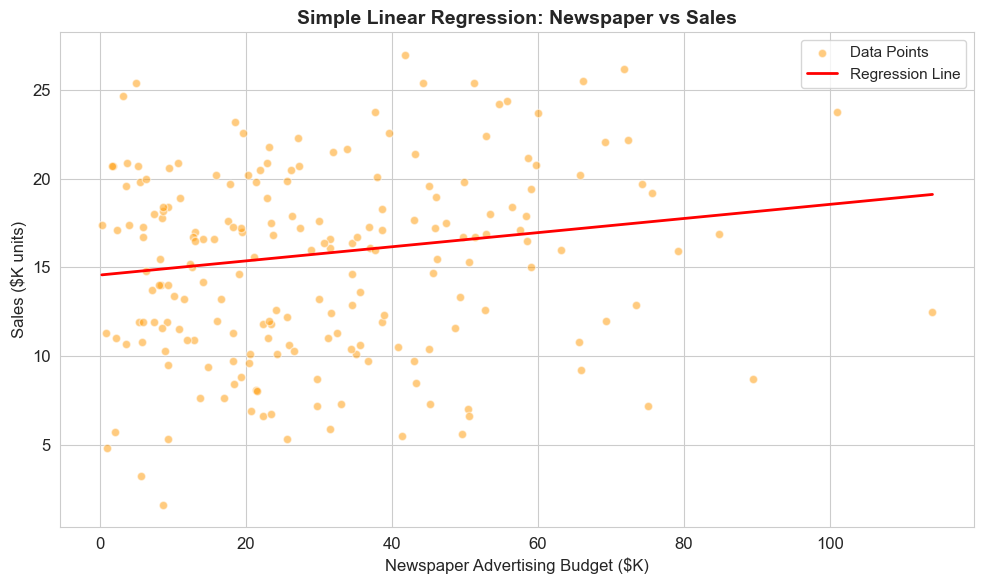

In [11]:
# Visualization: Regression line for Newspaper vs Sales
plt.figure(figsize=(10, 6))
plt.scatter(df['Newspaper'], df['Sales'], alpha=0.5, color='#FF9800', label='Data Points', edgecolors='white')

x_range = np.linspace(df['Newspaper'].min(), df['Newspaper'].max(), 100).reshape(-1, 1)
plt.plot(x_range, results_newspaper['model'].predict(x_range), color='red', linewidth=2, label='Regression Line')

plt.xlabel('Newspaper Advertising Budget ($K)', fontsize=12)
plt.ylabel('Sales ($K units)', fontsize=12)
plt.title('Simple Linear Regression: Newspaper vs Sales', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Interpretation (Newspaper → Sales):**
- The Newspaper model shows a very weak relationship with Sales.
- The low R² score indicates that Newspaper advertising budget alone explains very little of the variability in Sales.
- The scatter plot confirms that data points are widely spread around the regression line, indicating poor predictive power.

---
### 4.3 Model 3: Radio → Sales

In [12]:
print('='*60)
print('MODEL 3: Radio → Sales')
print('='*60)
results_radio = build_and_evaluate_model(df, 'Radio')

MODEL 3: Radio → Sales
Training set size: 140
Testing set size:  60

Regression Equation: Sales = 12.7993 + 0.1268 × Radio
Intercept (β0): 12.7993
Slope (β1):     0.1268

--- Evaluation Metrics (Test Set) ---
R² Score:                    -0.0443
Mean Squared Error (MSE):    29.2161
Root Mean Squared Error (RMSE): 5.4052
Mean Absolute Error (MAE):   4.6489


/opt/anaconda3/envs/DS201/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


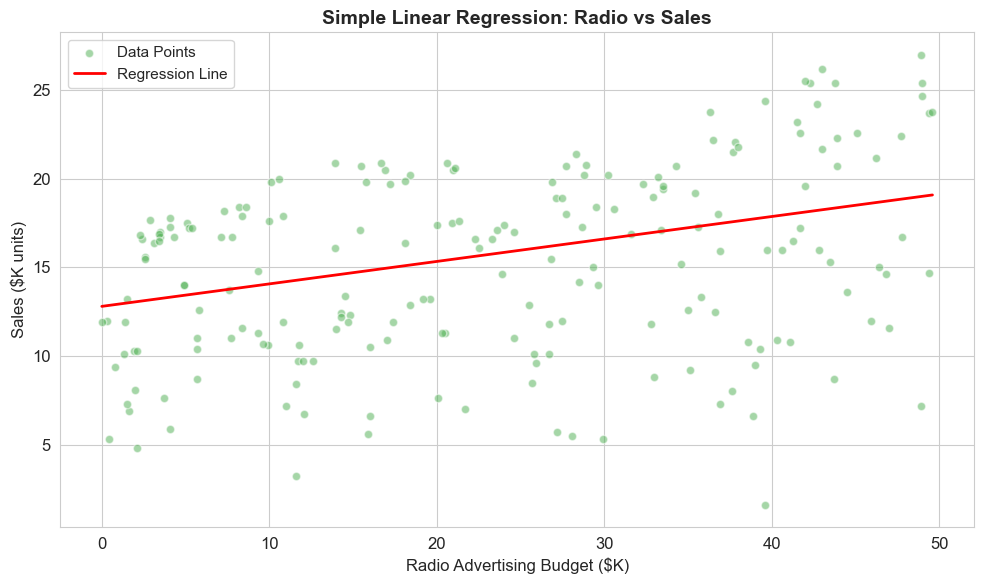

In [13]:
# Visualization: Regression line for Radio vs Sales
plt.figure(figsize=(10, 6))
plt.scatter(df['Radio'], df['Sales'], alpha=0.5, color='#4CAF50', label='Data Points', edgecolors='white')

x_range = np.linspace(df['Radio'].min(), df['Radio'].max(), 100).reshape(-1, 1)
plt.plot(x_range, results_radio['model'].predict(x_range), color='red', linewidth=2, label='Regression Line')

plt.xlabel('Radio Advertising Budget ($K)', fontsize=12)
plt.ylabel('Sales ($K units)', fontsize=12)
plt.title('Simple Linear Regression: Radio vs Sales', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Interpretation (Radio → Sales):**
- The Radio model shows a moderate relationship with Sales.
- The R² score indicates that Radio advertising alone explains a moderate portion of Sales variability — better than Newspaper but weaker than TV.
- The scatter around the regression line is moderate.

---
## 5. Model Comparison

Now let's compare all three models side-by-side using the evaluation metrics discussed in the lecture.

In [14]:
# Create comparison DataFrame
comparison = pd.DataFrame({
    'Model': ['TV → Sales', 'Newspaper → Sales', 'Radio → Sales'],
    'Feature': ['TV', 'Newspaper', 'Radio'],
    'Intercept (β0)': [results_tv['intercept'], results_newspaper['intercept'], results_radio['intercept']],
    'Slope (β1)': [results_tv['slope'], results_newspaper['slope'], results_radio['slope']],
    'R² Score': [results_tv['R2'], results_newspaper['R2'], results_radio['R2']],
    'MSE': [results_tv['MSE'], results_newspaper['MSE'], results_radio['MSE']],
    'RMSE': [results_tv['RMSE'], results_newspaper['RMSE'], results_radio['RMSE']],
    'MAE': [results_tv['MAE'], results_newspaper['MAE'], results_radio['MAE']]
})

# Display comparison table
print('='*80)
print('MODEL COMPARISON TABLE')
print('='*80)
comparison.round(4)

MODEL COMPARISON TABLE


,Model,Feature,Intercept (β0),Slope (β1),R² Score,MSE,RMSE,MAE
0,TV → Sales,TV,7.2066,0.0548,0.8149,5.1795,2.2759,1.8069
1,Newspaper → Sales,Newspaper,14.5662,0.0399,-0.1435,31.9888,5.6559,4.8081
2,Radio → Sales,Radio,12.7993,0.1268,-0.0443,29.2161,5.4052,4.6489


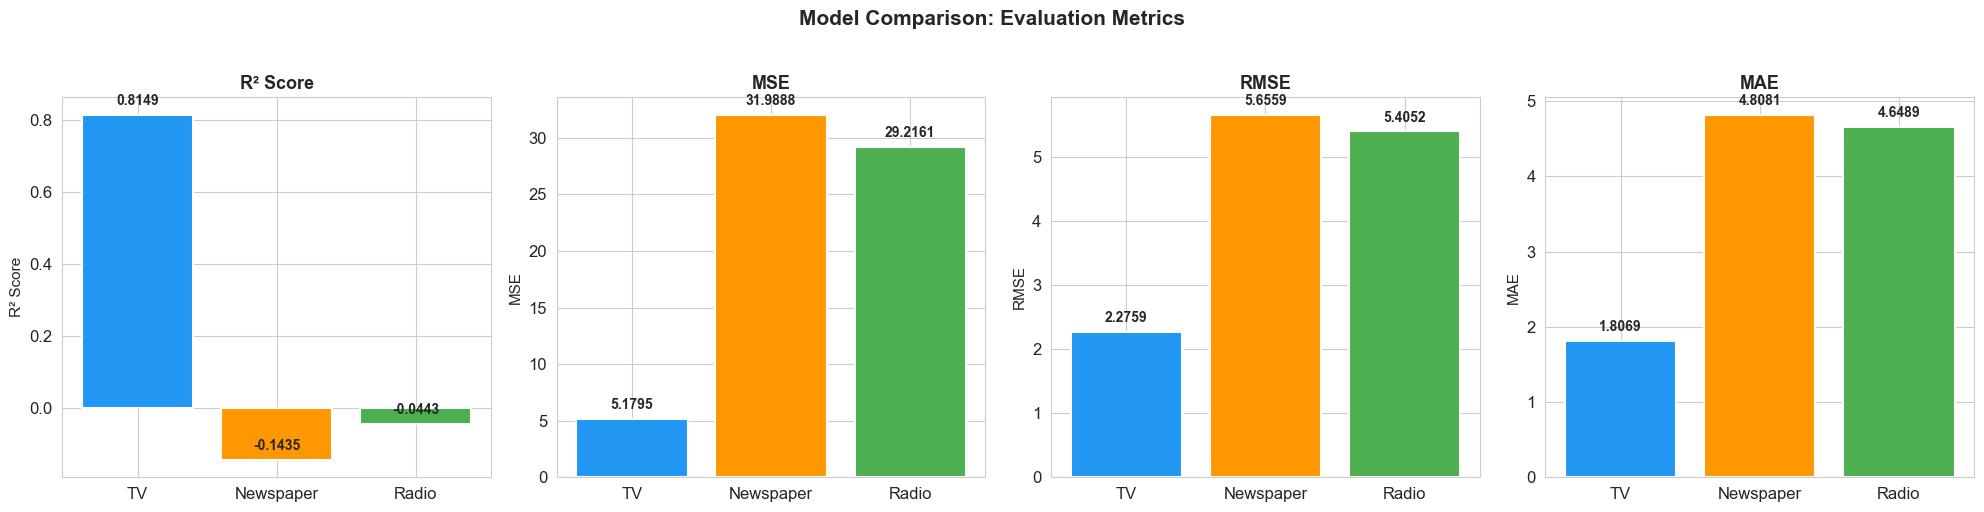

In [15]:
# Visual comparison of metrics
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

metrics = ['R² Score', 'MSE', 'RMSE', 'MAE']
colors_bar = ['#2196F3', '#FF9800', '#4CAF50']
models = ['TV', 'Newspaper', 'Radio']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(models, comparison[metric], color=colors_bar, edgecolor='white', linewidth=1.5)
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_ylabel(metric, fontsize=11)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[i].annotate(f'{height:.4f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 5), textcoords='offset points',
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Model Comparison: Evaluation Metrics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Actual vs Predicted Values Comparison

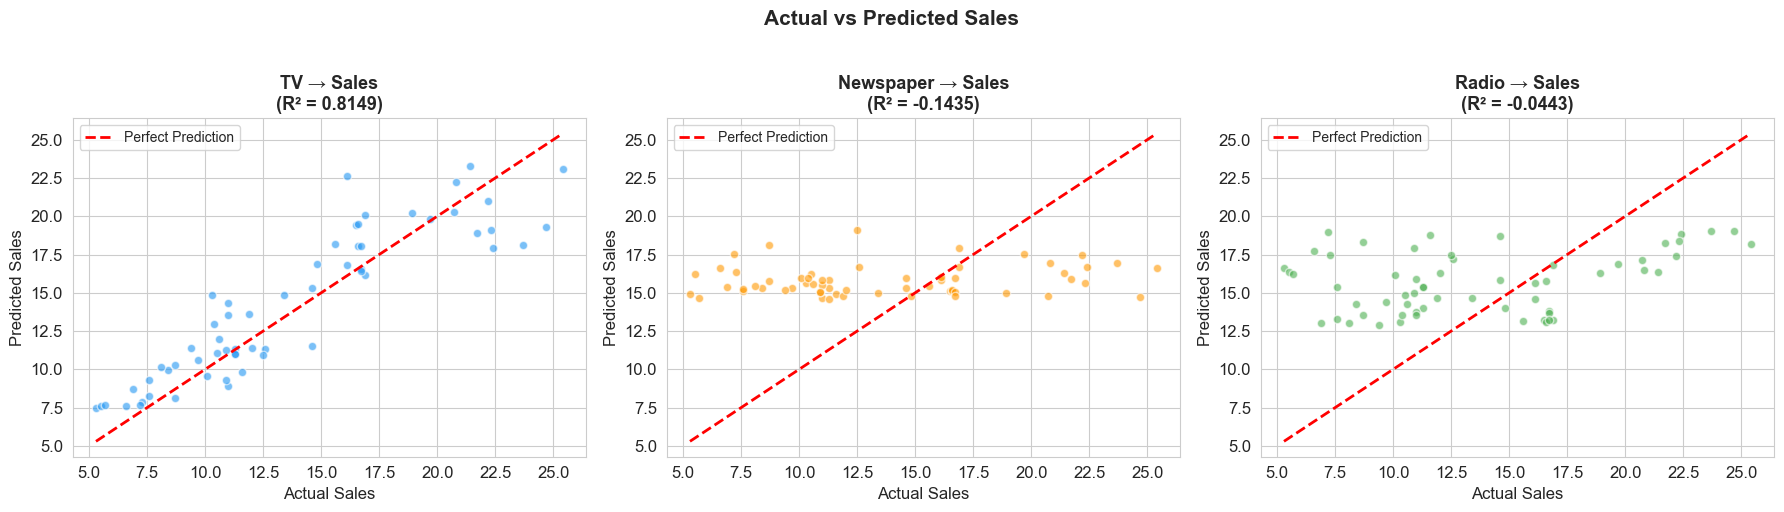

In [16]:
# Actual vs Predicted plots for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

all_results = [results_tv, results_newspaper, results_radio]
titles = ['TV → Sales', 'Newspaper → Sales', 'Radio → Sales']
colors_pred = ['#2196F3', '#FF9800', '#4CAF50']

for i, (result, title, color) in enumerate(zip(all_results, titles, colors_pred)):
    axes[i].scatter(result['y_test'], result['y_pred'], alpha=0.6, color=color, edgecolors='white')
    
    # Perfect prediction line
    min_val = min(result['y_test'].min(), result['y_pred'].min())
    max_val = max(result['y_test'].max(), result['y_pred'].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    axes[i].set_xlabel('Actual Sales', fontsize=12)
    axes[i].set_ylabel('Predicted Sales', fontsize=12)
    axes[i].set_title(f'{title}\n(R² = {result["R2"]:.4f})', fontsize=13, fontweight='bold')
    axes[i].legend(fontsize=10)

plt.suptitle('Actual vs Predicted Sales', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observation:** In the Actual vs Predicted plots, the closer the points are to the red dashed line (perfect prediction), the better the model. The TV model shows the tightest clustering around the line, confirming it is the best predictor.

---
## 7. Best Model Selection & Rationale

### Evaluation Criteria

We use the following metrics to evaluate each model:

| Metric | What it Measures | Best Value |
|--------|-----------------|------------|
| **R² (Coefficient of Determination)** | Proportion of variance in Sales explained by the feature | Closer to 1.0 |
| **MSE (Mean Squared Error)** | Average of squared differences between actual and predicted | Lower is better |
| **RMSE (Root Mean Squared Error)** | Square root of MSE; in the same unit as Sales | Lower is better |
| **MAE (Mean Absolute Error)** | Average of absolute differences between actual and predicted | Lower is better |

In [17]:
# Highlight the best model
print('='*70)
print('FINAL MODEL COMPARISON & BEST MODEL SELECTION')
print('='*70)
print()

# Determine best model based on R²
best_idx = comparison['R² Score'].idxmax()
best_model_name = comparison.loc[best_idx, 'Model']

print(f'Model Rankings (by R² Score, higher is better):')
print('-'*50)
ranking = comparison.sort_values('R² Score', ascending=False).reset_index(drop=True)
ranking.index = ranking.index + 1  # 1-based ranking
ranking.index.name = 'Rank'
print(ranking[['Model', 'R² Score', 'RMSE', 'MAE']].to_string())
print()
print(f'✅ BEST MODEL: {best_model_name}')
print(f'   - Highest R² Score: {comparison.loc[best_idx, "R² Score"]:.4f}')
print(f'   - Lowest RMSE:      {comparison.loc[best_idx, "RMSE"]:.4f}')
print(f'   - Lowest MAE:       {comparison.loc[best_idx, "MAE"]:.4f}')

FINAL MODEL COMPARISON & BEST MODEL SELECTION

Model Rankings (by R² Score, higher is better):
--------------------------------------------------
                  Model  R² Score      RMSE       MAE
Rank                                                 
1            TV → Sales  0.814855  2.275857  1.806912
2         Radio → Sales -0.044342  5.405188  4.648947
3     Newspaper → Sales -0.143453  5.655860  4.808109

✅ BEST MODEL: TV → Sales
   - Highest R² Score: 0.8149
   - Lowest RMSE:      2.2759
   - Lowest MAE:       1.8069


---
## 8. Conclusion

### Best Model: **TV → Sales**

Among the three simple linear regression models, the **TV → Sales** model is the best predictor of Sales. Here is the rationale:

### Rationale:

1. **Highest R² Score:** The TV model has the highest R² value, meaning it explains the largest proportion of variance in Sales compared to Newspaper and Radio models. A high R² indicates that the model fits the data well.

2. **Lowest Error Metrics (MSE, RMSE, MAE):** The TV model produces the smallest prediction errors across all error metrics. This means the predicted Sales values from the TV model are closest to the actual Sales values.

3. **Strongest Linear Relationship:** The scatter plot and correlation analysis both confirm that TV advertising has the strongest linear relationship with Sales (~0.90 correlation), making it the most reliable single predictor.

4. **Visual Confirmation:** The Actual vs Predicted plot for the TV model shows points clustered tightly around the perfect prediction line, confirming superior predictive accuracy.

### Model Rankings (Best to Worst):
1. **TV → Sales** — Strong predictor, high R², low errors
2. **Radio → Sales** — Moderate predictor, moderate R², moderate errors
3. **Newspaper → Sales** — Weak predictor, low R², high errors

### Practical Insight:
If a business had to choose **one** advertising channel to invest in based on this analysis, **TV advertising** would be the most effective channel for driving Sales. However, it is worth noting that a **multiple linear regression** model combining all features could potentially provide even better predictions than any single feature alone.